# 260710 F - several tasks but here are the highlights

* plot the OGOG Herguedas data
* redo their index system and make it closer to concentration.. need the original paper here to do that
* redo Gregory's method so that we can do any concentration

also related but separately 

* run the files that do KK transformations so that we can spot the issue
* keep track of what files and methods i am using for this, windows vs linux, .pyc files, which github files are similar or different
* figure out why we are on this in the first place... see flagged gregory email for details.

also separately separately but still important

* plan next steps with Colter and Andrew
* look at original summer docs for help getting back on track
* 

In [86]:
pip install scipy

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 78.3 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as sc

first of all i did not know that this masking trick would work and that is very cool

In [7]:
w = np.asarray([1,2,3,4,5])
mask = [True, False, True, False, True]
w[mask]

array([1, 3, 5])

next to plotting all of the OGOG Herguedas data. learned something very cool with this that you can pass multiple things into one `ax.plot` if you do it carefully. the df0.filter method is very good and simple to do. `^n` basically means `begins with n` and so i changed that to `k` for the second plot and that does it

In [8]:
df0 = pd.read_excel('cleaned_data.xlsx')

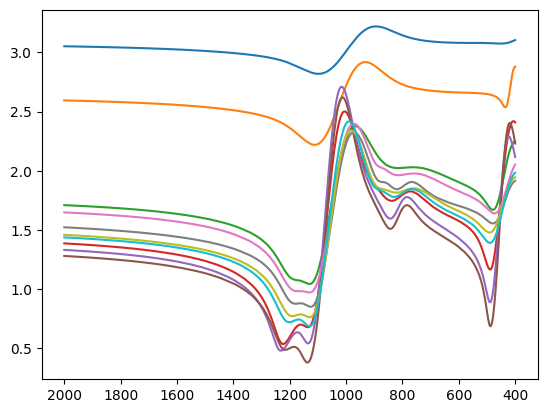

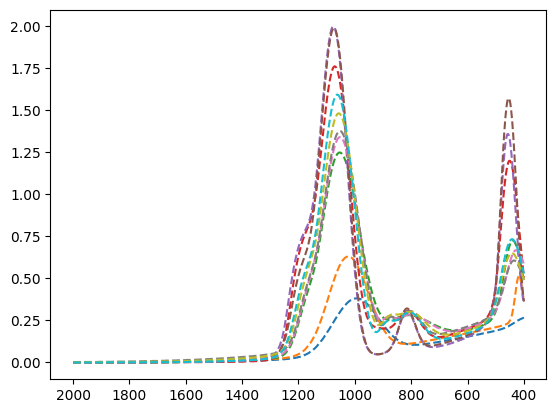

In [9]:
fig0, ax0 = plt.subplots()

ax0.plot(df0['Wavenumber (cm-1)'], df0.filter(regex=r'^n'))
ax0.invert_xaxis()

fig0.show()

fig1, ax1 = plt.subplots()

ax1.plot(df0['Wavenumber (cm-1)'], df0.filter(regex=r'^k'), '--')
ax1.invert_xaxis()

fig1.show()

Now how does that translate into what we are doing? What are these percentages or whatever and how do we cast those into the concentrations or whatever that we are using.

Here is the paper

[https://doi.org/10.3390/nano13202749]


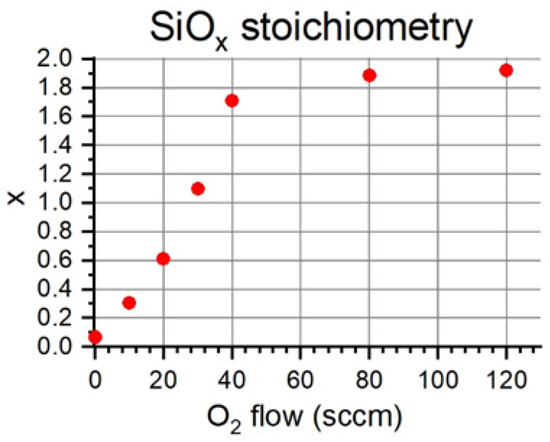

from that image we can see the flow rate and relate that to the stiochiometry

so here is a table summarizing this:

| O$_2$ flow | x |
| --- | --- |
| 0 | 0.06 |
| 10 | 0.3 |
| 20 | 0.61 |
| 30 | 1.1 |
| 40 | 1.71 |
| 80 | 1.85 |
| 120 | 1.92 |

There is no data in the paper to relate concentration to flow rate around 31-34, so that could be something that we should do and then test how similar our calculated values are to the measured values in this range.

Also I want to check these values that are in the excel sheet and compare them to the original data in the supplementary info.


In [10]:
df0[df0['Wavenumber (cm-1)'] == 960]

,Wavenumber (cm-1),Wavelength (μm),n10,k10,n20,k20,n30,k30,n40,k40,...,n120,k120,n31,k31,n32,k32,n33,k33,n34,k34
520,960,10.417,3.131,0.354,2.885,0.448,2.373,0.572,2.218,0.288,...,2.154,0.109,2.381,0.535,2.309,0.529,2.28,0.452,2.29,0.352


In [11]:
df1 = df0.filter(regex=r'^n.*0$')
df1['Wavenumber'] = df0['Wavenumber (cm-1)']
df1['Wavelength um'] = df0['Wavelength (μm)']
df1

/tmp/ipykernel_1233398/2861524364.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Wavenumber'] = df0['Wavenumber (cm-1)']
/tmp/ipykernel_1233398/2861524364.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Wavelength um'] = df0['Wavelength (μm)']


,n10,n20,n30,n40,n80,n120,Wavenumber,Wavelength um
0,3.051,2.594,1.710,1.387,1.332,1.281,2000,5.000
1,3.051,2.594,1.710,1.387,1.332,1.281,1998,5.005
2,3.051,2.594,1.710,1.387,1.332,1.280,1996,5.010
3,3.051,2.594,1.709,1.386,1.331,1.280,1994,5.015
4,3.051,2.593,1.709,1.386,1.331,1.280,1992,5.020
...,...,...,...,...,...,...,...,...
796,3.095,2.839,2.231,2.418,2.202,2.333,408,24.510
797,3.097,2.856,2.238,2.419,2.181,2.310,406,24.631
798,3.099,2.868,2.242,2.417,2.159,2.285,404,24.752
799,3.101,2.876,2.246,2.414,2.138,2.258,402,24.876


n(x) = 0.000347353x^2 + -0.0588359x + 3.45646


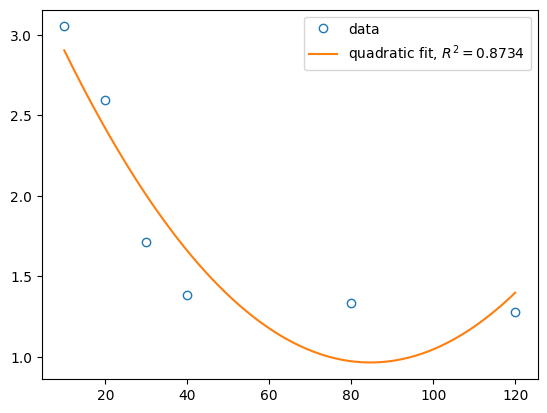

In [12]:
row = df1[df1['Wavenumber'] == 2000]
#row = df1.loc[df1['Wavenumber'] == 960].squeeze()
n = row.filter(regex='^n').squeeze()
#x = n.columns.str[1:].astype(float)
x = n.index.str[1:].astype(float)

fig2, ax2 = plt.subplots()

ax2.plot(x, n, 'o', mfc='none', label='data')

#y = n.iloc[0].to_numpy(dtype=float)

coeff = np.polyfit(x, n, 2)
a, b, c = coeff

xfit = np.linspace(x.min(), x.max(), 200)
yfit = np.polyval(coeff, xfit)

ypred = np.polyval(coeff, x)
ss_res = np.sum((n - ypred)**2)
ss_tot = np.sum((n - n.mean())**2)
r2 = 1 - ss_res / ss_tot

ax2.plot(xfit, yfit, '-', label=f'quadratic fit, $R^2={r2:.4f}$')

ax2.legend()

print(f'n(x) = {a:.6g}x^2 + {b:.6g}x + {c:.6g}') # x + {d:.6g}')

In [13]:
a_list = []
b_list = []
c_list = []

for i in range(len(df1)):
    row = df1.iloc[i]
    #row = df1.loc[df1['Wavenumber'] == 960].squeeze()
    n = row.filter(regex='^n').squeeze()
    #x = n.columns.str[1:].astype(float)
    x = n.index.str[1:].astype(float)
    
    #fig2, ax2 = plt.subplots()
    
    #ax2.plot(x, n, 'o', mfc='none', label='data')
    
    #y = n.iloc[0].to_numpy(dtype=float)
    
    coeff = np.polyfit(x, n, 2)
    a, b, c = coeff

    a_list.append(a)
    b_list.append(b)
    c_list.append(c)
    #xfit = np.linspace(x.min(), x.max(), 200)
    #yfit = np.polyval(coeff, xfit)
    
    #ypred = np.polyval(coeff, x)
    #ss_res = np.sum((n - ypred)**2)
    #ss_tot = np.sum((n - n.mean())**2)
    #r2 = 1 - ss_res / ss_tot
    
    #ax2.plot(xfit, yfit, '-', label=f'quadratic fit, $R^2={r2:.4f}$')
    
    #ax2.legend()
    
    #print(f'n(x) = {a:.6g}x^3 + {b:.6g}x^2 + {c:.6g}') # x + {d:.6g}')
    

In [14]:
a_list

[np.float64(0.00034735317116469814),
 np.float64(0.00034735317116469814),
 np.float64(0.000347173848722447),
 np.float64(0.000347592302977788),
 np.float64(0.0003475429549633326),
 np.float64(0.0003473531711646978),
 np.float64(0.00034732168142528094),
 np.float64(0.0003475291121584208),
 np.float64(0.0003475923029777882),
 np.float64(0.0003475923029777882),
 np.float64(0.0003475608132383709),
 np.float64(0.0003477682439715114),
 np.float64(0.00034783143479087865),
 np.float64(0.0003476027643341717),
 np.float64(0.0003479580277701461),
 np.float64(0.0003479580277701461),
 np.float64(0.0003479580277701461),
 np.float64(0.000348007375784602),
 np.float64(0.000348007375784602),
 np.float64(0.000348007375784602),
 np.float64(0.0003478280533423507),
 np.float64(0.00034819715958323645),
 np.float64(0.00034819715958323645),
 np.float64(0.00034819715958323645),
 np.float64(0.00034837310057695965),
 np.float64(0.000348436291396327),
 np.float64(0.000348436291396327),
 np.float64(0.0003484643996

In [15]:
df1['a'] = a_list

/tmp/ipykernel_1233398/4078249893.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['a'] = a_list


In [16]:
df1['b'] = b_list
df1['c'] = c_list

/tmp/ipykernel_1233398/2302690845.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['b'] = b_list
/tmp/ipykernel_1233398/2302690845.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['c'] = c_list


In [17]:
print(df1.to_string())

       n10    n20    n30    n40    n80   n120  Wavenumber  Wavelength um         a         b         c
0    3.051  2.594  1.710  1.387  1.332  1.281        2000          5.000  0.000347 -0.058836  3.456462
1    3.051  2.594  1.710  1.387  1.332  1.281        1998          5.005  0.000347 -0.058836  3.456462
2    3.051  2.594  1.710  1.387  1.332  1.280        1996          5.010  0.000347 -0.058820  3.456233
3    3.051  2.594  1.709  1.386  1.331  1.280        1994          5.015  0.000348 -0.058875  3.456807
4    3.051  2.593  1.709  1.386  1.331  1.280        1992          5.020  0.000348 -0.058865  3.456343
5    3.050  2.593  1.709  1.386  1.331  1.280        1990          5.025  0.000347 -0.058836  3.455462
6    3.050  2.593  1.709  1.385  1.331  1.279        1988          5.030  0.000347 -0.058839  3.455389
7    3.050  2.593  1.709  1.385  1.330  1.279        1986          5.035  0.000348 -0.058869  3.455925
8    3.050  2.593  1.708  1.385  1.330  1.279        1984          5.040 

In [18]:
n15 = df1.a*15**2 + df1.b*15 + df1.c

In [19]:
n15

0      2.652078
1      2.652078
2      2.652040
3      2.651888
4      2.651561
         ...   
796    2.870815
797    2.880550
798    2.887869
799    2.893595
800    2.897137
Length: 801, dtype: float64

In [20]:
ColterKK(n15) -> k15

SyntaxError: invalid syntax (2712321548.py, line 1)

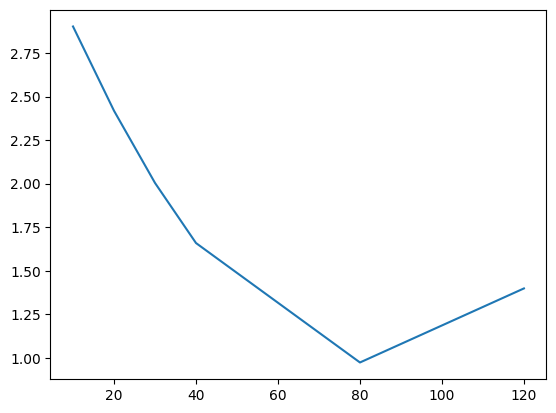

In [21]:
fig5, ax5 = plt.subplots()
ax5.plot(x, a_list[0]*x**2+b_list[0]*x+c_list[0])

In [22]:
x

Index([10.0, 20.0, 30.0, 40.0, 80.0, 120.0], dtype='float64')

In [2]:
def power_law_offset(x, a, b, c):
    return a * x**b + c

popt, pcov = sc.curve_fit(
    power_law_offset,
    x,
    n,
    p0=(1, -1, 2)
)

a, b, c = popt

xfit = np.linspace(x.min(), x.max(), 200)
yfit = power_law_offset(xfit, a, b, c)

ypred = power_law_offset(x, a, b, c)

ss_res = np.sum((n - ypred)**2)
ss_tot = np.sum((n - n.mean())**2)
r2 = 1 - ss_res / ss_tot

fig3, ax3 = plt.subplots()
ax3.plot(x, n, 'o', mfc='none', label='data')
ax3.plot(
    xfit,
    yfit,
    label=fr'$y={a:.3g}x^{{{b:.3g}}}+{c:.3g}$, $R^2={r2:.4f}$'
)

ax3.legend()

NameError: name 'sc' is not defined

ok now to look at the k values with very similar code

In [3]:
df2 = df0.filter(regex=r'^k.*0$')
df2['Wavenumber'] = df0['Wavenumber (cm-1)']
df2['Wavelength um'] = df0['Wavelength (μm)']
df2

NameError: name 'df0' is not defined

In [4]:
row = df2[df2['Wavenumber'] == 1260]
#row = df1.loc[df1['Wavenumber'] == 960].squeeze()
k = row.filter(regex='^k').squeeze()
#x = n.columns.str[1:].astype(float)
x = n.index.str[1:].astype(float)

fig4, ax4 = plt.subplots()

ax4.plot(x, k, 'o', mfc='none', label='data')

#y = n.iloc[0].to_numpy(dtype=float)

coeff = np.polyfit(x, k, 2)
a, b, c = coeff

xfit = np.linspace(x.min(), x.max(), 200)
yfit = np.polyval(coeff, xfit)

ypred = np.polyval(coeff, x)
ss_res = np.sum((k - ypred)**2)
ss_tot = np.sum((k - k.mean())**2)
r2 = 1 - ss_res / ss_tot

ax4.plot(xfit, yfit, '-', label=f'fit, $R^2={r2:.4f}$')

ax4.legend()

print(f'n(x) = {a:.6g}x^2 + {b:.6g}x + {c:.6g}')#x + {d:.6g}')

NameError: name 'df2' is not defined

In [5]:
popt, pcov = sc.curve_fit(
    power_law_offset,
    x,
    k,
    p0=(k.max()-k.min(), -1, k.min()),
    maxfev=10000
)

a, b, c = popt

xfit = np.linspace(x.min(), x.max(), 200)
yfit = power_law_offset(xfit, a, b, c)

ypred = power_law_offset(x, a, b, c)

ss_res = np.sum((k - ypred)**2)
ss_tot = np.sum((k - k.mean())**2)
r2 = 1 - ss_res / ss_tot

fig5, ax5 = plt.subplots()
ax5.plot(x, k, 'o', mfc='none', label='data')
ax5.plot(
    xfit,
    yfit,
    label=fr'$y={a:.3g}x^{{{b:.3g}}}+{c:.3g}$, $R^2={r2:.4f}$'
)

ax5.legend()

NameError: name 'sc' is not defined

In [ ]:
## 